In [2]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
import joblib

In [3]:
# Load Dataset
print("📦 Initializing Memory-Optimized Zip Ingestion Engine...")

tuesday_zip = 'Datasets/Tuesday-WorkingHours.pcap_ISCX.csv.zip'
wednesday_zip = 'Datasets/Wednesday-workingHours.pcap_ISCX.csv.zip'

processed_chunks = []

# 1. Parse Tuesday Compressed Data (Brute Force)
for chunk in pd.read_csv(tuesday_zip, compression='zip', chunksize=50000):
    chunk.columns = chunk.columns.str.strip()
    brute_rows = chunk[chunk['Label'].str.contains('Patator|Brute', case=False, na=False)]
    benign_rows = chunk[chunk['Label'].str.contains('BENIGN', case=False, na=False)].sample(frac=0.03, random_state=42)
    processed_chunks.append(pd.concat([brute_rows, benign_rows]))

# 2. Parse Wednesday Compressed Data (DoS/DDoS)
for chunk in pd.read_csv(wednesday_zip, compression='zip', chunksize=50000):
    chunk.columns = chunk.columns.str.strip()
    ddos_rows = chunk[chunk['Label'].str.contains('DDoS|DoS', case=False, na=False)]
    benign_rows = chunk[chunk['Label'].str.contains('BENIGN', case=False, na=False)].sample(frac=0.03, random_state=42)
    processed_chunks.append(pd.concat([ddos_rows, benign_rows]))

# Consolidate memory chunks
df = pd.concat(processed_chunks, axis=0, ignore_index=True)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(subset=['Destination Port', 'Label'], inplace=True)

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

📦 Initializing Memory-Optimized Zip Ingestion Engine...
First 5 Rows:
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0                80        5216127                  3                       1   
1                21             20                  1                       1   
2                21             38                  1                       1   
3                21             80                  1                       1   
4                21             68                  1                       1   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                            0                            0   
1                            0                            0   
2                            0                            0   
3                            0                            0   
4                            0                            0   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Leng

In [4]:
# Feature (Input) and Target (Output)
def encode_label(val):
    val = str(val).upper()
    if 'BENIGN' in val: return 0
    elif 'DDOS' in val or 'DOS' in val: return 1
    elif 'PATATOR' in val or 'BRUTE' in val: return 2
    return 0

df['Target_Class'] = df['Label'].apply(encode_label)

feature_map = {
    'Destination Port': 'DST_PORT',
    'Flow Duration': 'FLOW_DURATION',
    'Total Fwd Packets': 'FWD_PKTS',
    'Total Backward Packets': 'BWD_PKTS',
    'Total Length of Fwd Packets': 'FWD_BYTES',
    'Total Length of Bwd Packets': 'BWD_BYTES' 
}

X = df[list(feature_map.keys())].copy()
X.rename(columns=feature_map, inplace=True)
y = df['Target_Class']

In [5]:
# Split Dataset & Scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nTraining Samples:", len(X_train_scaled))
print("Testing Samples:", len(X_test_scaled))


Training Samples: 234125
Testing Samples: 58532


In [6]:
# Create Model
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    objective='multi:softprob',
    num_class=3,
    random_state=42
)

In [7]:
# Train Model
model.fit(X_train_scaled, y_train)
print("\nModel Training Completed")


Model Training Completed


In [8]:
# Model Features Breakdown (Replaces Linear Equation)
for feature, importance in zip(X.columns, model.feature_importances_):
    print(f"{feature}: {importance:.4f}")

DST_PORT: 0.8850
FLOW_DURATION: 0.0160
FWD_PKTS: 0.0083
BWD_PKTS: 0.0432
FWD_BYTES: 0.0114
BWD_BYTES: 0.0361


In [9]:
# Predictions
y_pred = model.predict(X_test_scaled)

print("\nPredicted Classes (0=Benign, 1=DDoS, 2=Brute Force):")
print(y_pred[:10])


Predicted Classes (0=Benign, 1=DDoS, 2=Brute Force):
[1 1 1 0 1 1 1 0 1 1]


In [10]:
from sklearn.neighbors import KNeighborsClassifier
print("Training Algorithm 1: K-Nearest Neighbors...")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_preds = knn_model.predict(X_test_scaled)
knn_acc = accuracy_score(y_test, knn_preds)
print("Training Algorithm 1: K-Nearest Neighbors - Successfully Completed")

Training Algorithm 1: K-Nearest Neighbors...
Training Algorithm 1: K-Nearest Neighbors - Successfully Completed


In [11]:
from sklearn.naive_bayes import GaussianNB
print("Training Algorithm 2: Naïve Bayes...")
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
nb_preds = nb_model.predict(X_test_scaled)
nb_acc = accuracy_score(y_test, nb_preds)
print("Training Algorithm 2: Naïve Bayes - Successfully Completed")

Training Algorithm 2: Naïve Bayes...
Training Algorithm 2: Naïve Bayes - Successfully Completed


In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)

# Train XGBoost
xgb_model.fit(X_train, y_train)

# Predict
xgb_pred = xgb_model.predict(X_test)

# Calculate accuracy
xgb_acc = accuracy_score(y_test, xgb_pred)

print(f"XGBoost Accuracy: {xgb_acc * 100:.3f}%")

XGBoost Accuracy: 99.595%


In [13]:
from sklearn.linear_model import LogisticRegression
print("Training Algorithm 3: Logistic Regression...")
lr_model = LogisticRegression(max_iter=500, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_preds)
print("Training Algorithm 3: Logistic Regression - Successfully Completed")

Training Algorithm 3: Logistic Regression...
Training Algorithm 3: Logistic Regression - Successfully Completed


In [14]:
print("\n" + "="*50)
print("             ALGORITHM COMPARISON REPORT")
print("="*50)
print(f"1. K-Nearest Neighbors (KNN) Acc : {knn_acc*100:.3f}%")
print(f"2. Naïve Bayes (Gaussian NB) Acc : {nb_acc*100:.3f}%")
print(f"3. Logistic Regression Accuracy  : {lr_acc*100:.3f}%")
print(f"4. XGBoost (Boosting) Accuracy : {xgb_acc*100:.3f}%")
print("="*50)


             ALGORITHM COMPARISON REPORT
1. K-Nearest Neighbors (KNN) Acc : 99.800%
2. Naïve Bayes (Gaussian NB) Acc : 98.978%
3. Logistic Regression Accuracy  : 91.010%
4. XGBoost (Boosting) Accuracy : 99.595%


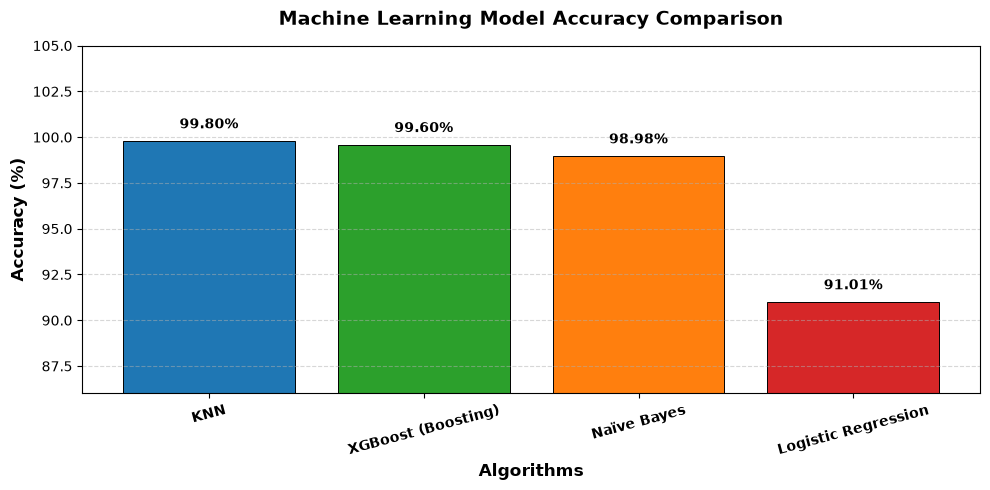

In [15]:
# Construct results DataFrame for the 4 models
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.DataFrame({
    "Algorithm": [
        "XGBoost (Boosting)", 
        "KNN", 
        "Naïve Bayes", 
        "Logistic Regression"
    ],
    "Accuracy (%)": [
        xgb_acc * 100, 
        knn_acc * 100, 
        nb_acc * 100, 
        lr_acc * 100
    ]
})

# Sort the models by accuracy (highest first) to make the chart look structured
results_df = results_df.sort_values(by="Accuracy (%)", ascending=False).reset_index(drop=True)

# Plot Accuracy Comparison Bar Chart
fig, ax = plt.subplots(figsize=(10, 5))

# Custom color palette for the 4 bars (matches your colors)
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

bars = ax.bar(
    results_df["Algorithm"], 
    results_df["Accuracy (%)"], 
    color=colors,
    edgecolor='black',
    linewidth=0.7
)

ax.set_ylabel("Accuracy (%)", fontsize=12, fontweight='bold')
ax.set_xlabel("Algorithms", fontsize=12, fontweight='bold')

# Start the y-axis a bit below the lowest accuracy to highlight the differences clearly
min_acc = min(results_df["Accuracy (%)"])
ax.set_ylim(max(0, int(min_acc - 5)), 105) 

ax.set_title("Machine Learning Model Accuracy Comparison", fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Write the exact percentage on top of each bar
for bar in bars:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2.0, 
        yval + 0.5, 
        f"{yval:.2f}%", 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold'
    )

plt.xticks(rotation=15, fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("\nAccuracy Score:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy Score: 0.9980865167771475

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99      5232
           1       1.00      1.00      1.00     50533
           2       1.00      1.00      1.00      2767

    accuracy                           1.00     58532
   macro avg       1.00      0.99      1.00     58532
weighted avg       1.00      1.00      1.00     58532



In [17]:
# Actual vs Predicted
results = pd.DataFrame({
    'Actual Class': y_test.values,
    'Predicted Class': y_pred
})

print("\nActual vs Predicted (First 10 Rows)")
print(results.head(10))


Actual vs Predicted (First 10 Rows)
   Actual Class  Predicted Class
0             1                1
1             1                1
2             1                1
3             0                0
4             1                1
5             1                1
6             1                1
7             0                0
8             1                1
9             1                1


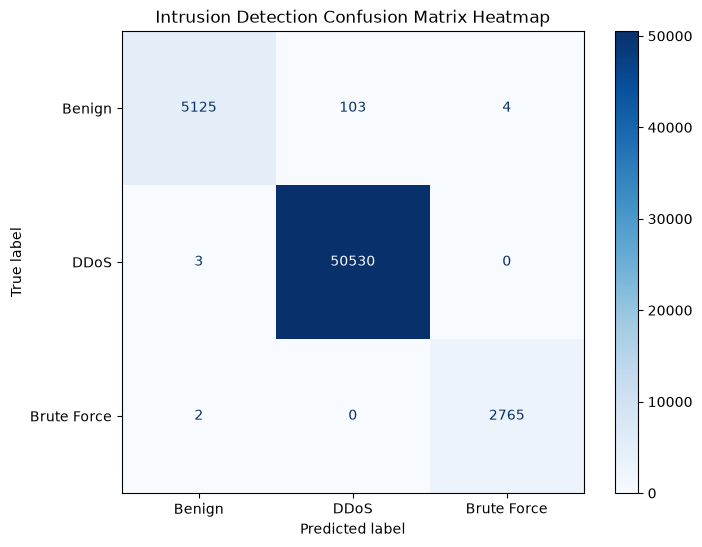

In [18]:
# Confusion Matrix Heatmap
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix array
cm = confusion_matrix(y_test, y_pred)

# Set up visual labels matching target classes (0 = Benign, 1 = DDoS, 2 = Brute Force)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'DDoS', 'Brute Force'])

# Plot styling
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('Intrusion Detection Confusion Matrix Heatmap')
plt.show()

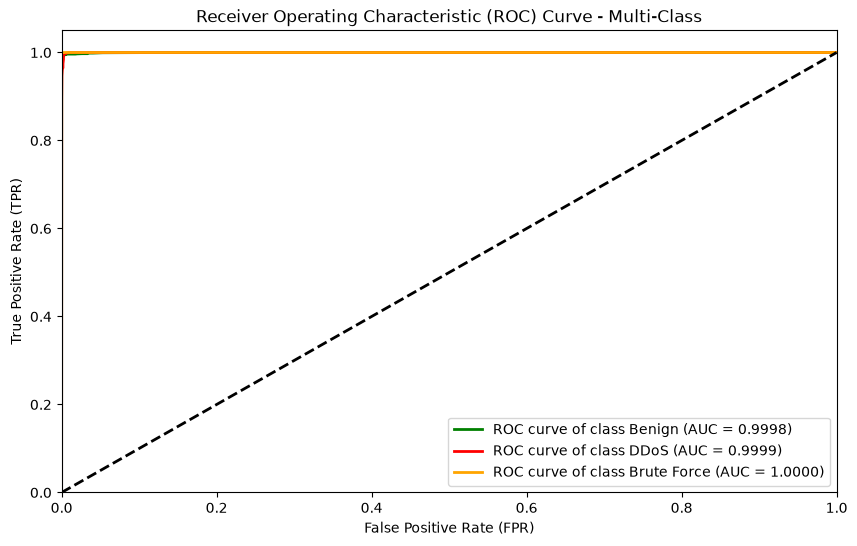

In [19]:
# Multi-class ROC Curve (One-vs-Rest)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binarize output classes for One-vs-Rest ROC evaluation
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = model.predict_proba(X_test_scaled)
n_classes = 3

fpr = dict()
tpr = dict()
roc_auc = dict()
classes_names = ['Benign', 'DDoS', 'Brute Force']
colors = ['green', 'red', 'orange']

plt.figure(figsize=(10, 6))

# Plot ROC curves for each threat class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'ROC curve of class {classes_names[i]} (AUC = {roc_auc[i]:.4f})')

# Plot diagonal baseline (representing a random model)
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve - Multi-Class')
plt.legend(loc="lower right")
plt.show()

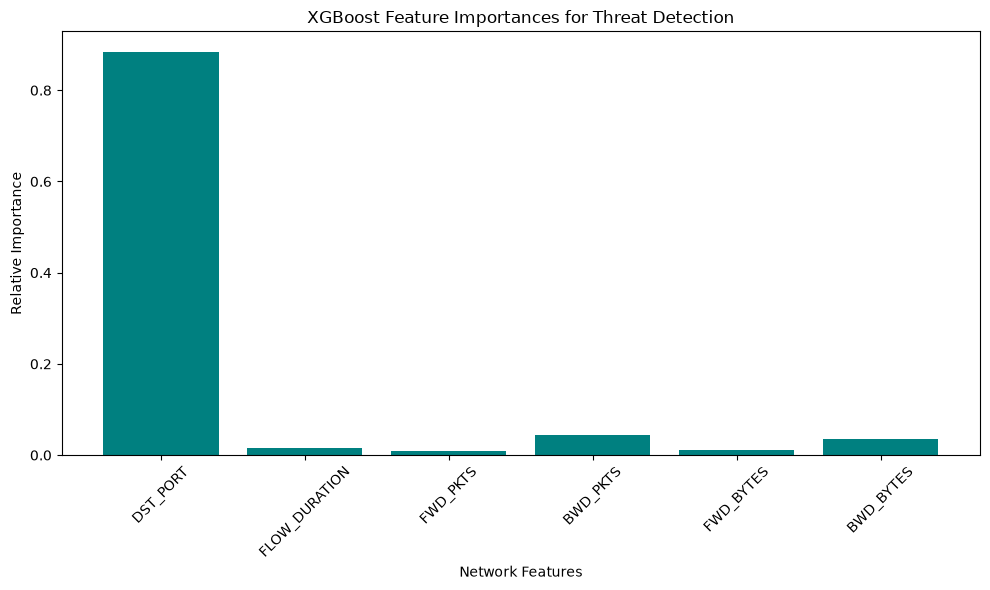

In [20]:
# Visualization
plt.figure(figsize=(10,6))
plt.bar(X.columns, model.feature_importances_, color='teal')
plt.xlabel("Network Features")
plt.ylabel("Relative Importance")
plt.title("XGBoost Feature Importances for Threat Detection")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# Custom Prediction / Save Artifacts
joblib.dump(model, 'cyber_threat_model.pkl')
joblib.dump(scaler, 'cyber_scaler.pkl')
joblib.dump(list(X.columns), 'cyber_features.pkl')

print("\nModel, Scaler, and Features saved successfully to disk!")


Model, Scaler, and Features saved successfully to disk!
